MIT License

Copyright © 2023-2025 Tohoku University

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

In [1]:
from qklearn.cluster import ConstrainedClustering
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

/home/gp.sc.cc.tohoku.ac.jp/kumagai/.pyenv/versions/anaconda3-4.3.0/envs/qkl/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


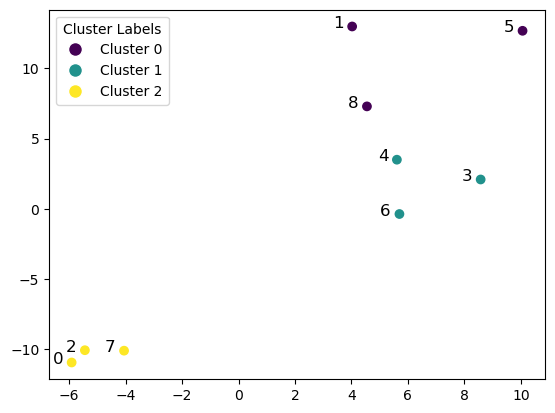

In [2]:
def get_artificial_data(n_clusters, n_points):
    data, labels = make_blobs(random_state=8,
                                    n_samples=n_points,
                                    n_features=2, 
                                    cluster_std=1.5,
                                    centers=n_clusters)
    return data, labels

data, labels_origin = get_artificial_data(n_clusters=3, n_points=9)

# 可視化
# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_origin)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_origin):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

Note: Please place `amplify-license.yaml` in the same directory as this notebook in advance.

In [ ]:
from amplify import FixstarsClient
from datetime import timedelta
from qklearn.utils import read_token

client = FixstarsClient()
client.token = read_token("Fixstars")
client.parameters.timeout = timedelta(milliseconds=1000)

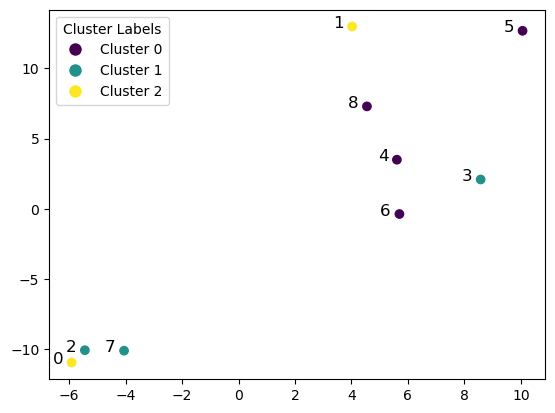

In [5]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_must_link_to_qubo([(0,1), (2,3), (4,5)])  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

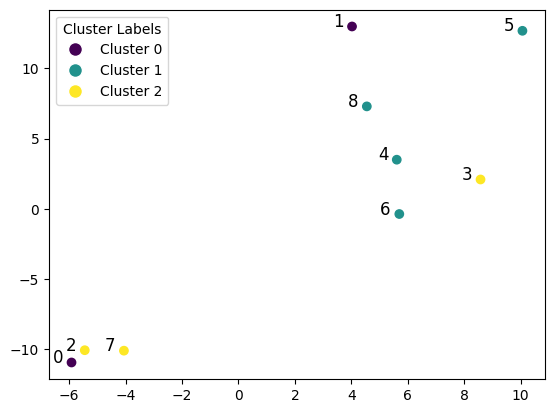

In [7]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.set_must_link_by_qbits_reduction([(0,1), (2,3), (4,5)])  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

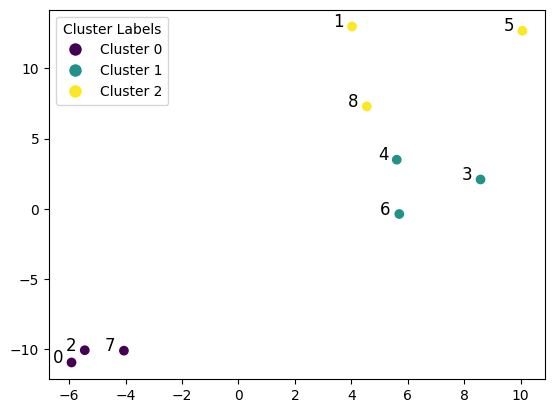

In [8]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_cannot_link_to_qubo([(0,1), (2,3), (4,5)])  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

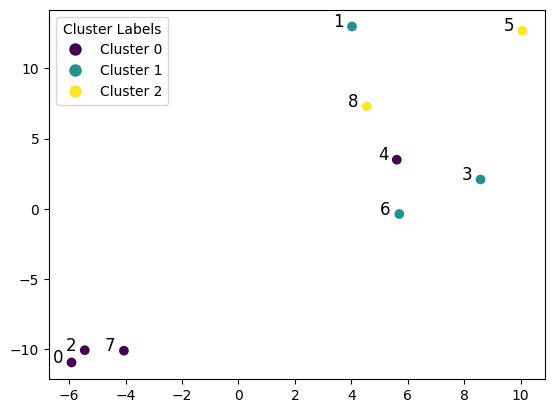

In [9]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_partition_level_to_qubo({0:(0,2,4),1:(1,3,6)})  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

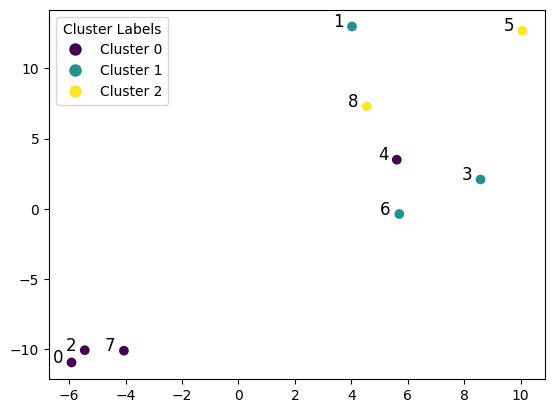

In [10]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.set_partition_level_by_qbits_reduction({0:(0,2,4),1:(1,3,6)})  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

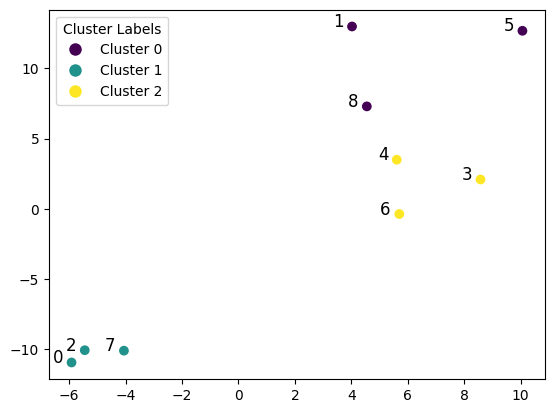

In [11]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_non_partition_level_to_qubo({0:(0,2,4),1:(1,3,6)})  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

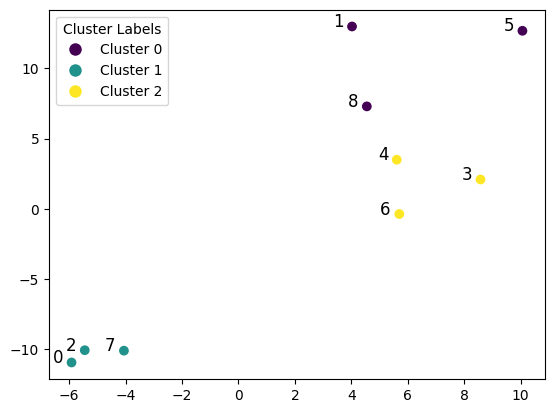

In [12]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.set_non_partition_level_by_qbits_reduction({0:(0,2,4),1:(1,3,6)})  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

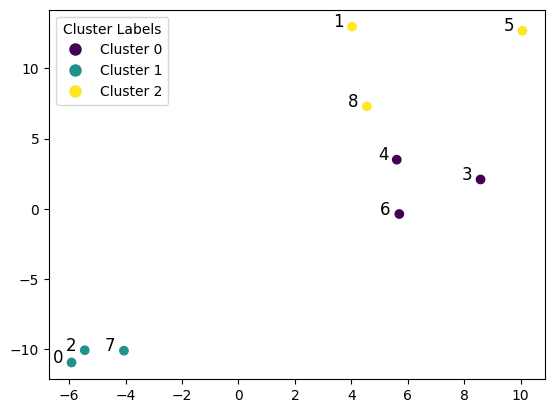

In [13]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_balanced_sizes_to_qubo()  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()

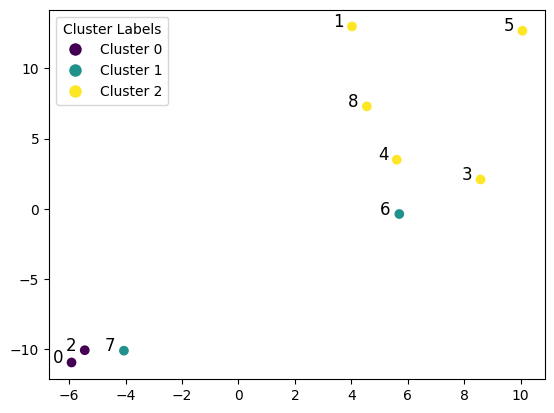

In [14]:
ccl = ConstrainedClustering(n_clusters=3)
ccl.fit(data)
ccl.add_limited_sizes_to_qubo({0:2, 1:2, 2:5})  # set a constraint
labels_ccl = ccl.predict(client)

# plot labels
scatter = plt.scatter(data[:,0], data[:,1], c=labels_ccl)
for i, (x, y) in enumerate(data):
    plt.text(x - 0.3, y - 0.3, str(i), fontsize=12, ha='right', va='bottom')

# show legend for each label
handles = []
labels = []
for label in set(labels_ccl):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {label}',
                              markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10))
    labels.append(f'Cluster {label}')
plt.legend(handles=handles, title="Cluster Labels")
plt.show()